## Introduction

La somnolence au volant est l’une des principales causes des accidents de la route à travers le monde. Détecter automatiquement l’état de vigilance du conducteur à partir d’images est donc un enjeu majeur de sécurité routière.  
Dans ce projet, nous proposons un système de classification d’images basé sur le Deep Learning afin de distinguer deux états du conducteur : **SafeDriving** (conduite normale) et **SleepyDriving** (conduite somnolente).

Nous utilisons un **réseau de neurones convolutifs (CNN) from scratch**, entraîné sur un dataset d’images hétérogènes (images en couleur et en niveaux de gris). Le projet couvre l’ensemble du pipeline Deep Learning : préparation des données, augmentation, entraînement, évaluation et analyse des performances à l’aide de métriques avancées.


## 1. Imports & Configuration

Dans cette partie, nous importons l’ensemble des bibliothèques nécessaires au projet.  
Les bibliothèques **TensorFlow/Keras** sont utilisées pour la construction et l’entraînement du modèle Deep Learning, tandis que **NumPy**, **Matplotlib** et **Seaborn** servent à la manipulation et à la visualisation des données.  
Enfin, **Scikit-learn** est utilisé pour l’évaluation du modèle à travers des métriques robustes comme la matrice de confusion, la courbe ROC et le rapport de classification.

Ce choix permet de séparer clairement la phase d’apprentissage de la phase d’évaluation, garantissant ainsi une analyse fiable et interprétable des résultats.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight


## 2. Paramètres Globaux

Cette section définit les hyperparamètres globaux du projet, tels que la taille des images, la taille du batch et le nombre d’époques.  
Nous avons fixé la taille des images à **224×224**, un compromis entre richesse visuelle et coût computationnel.  
Le choix de deux classes correspond directement à la nature binaire du problème étudié : conduite normale ou somnolente.

La séparation du dataset en dossiers **train / validation / test** permet d’éviter le surapprentissage et d’évaluer objectivement la capacité de généralisation du modèle.


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 2

DATASET_DIR = r"C:\Users\Lenovo\Documents\DeepLearning\dataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")


## 3. Analyse de la Distribution des Classes

Avant l’entraînement, il est essentiel d’analyser la distribution des classes dans le dataset.  
Cette étape permet de détecter un éventuel déséquilibre entre les classes, fréquent dans les problèmes réels liés à la sécurité routière.

Une telle analyse justifie l’utilisation ultérieure de techniques de compensation, comme les **class weights**, afin d’éviter que le modèle ne favorise la classe majoritaire au détriment de la classe critique (SleepyDriving).


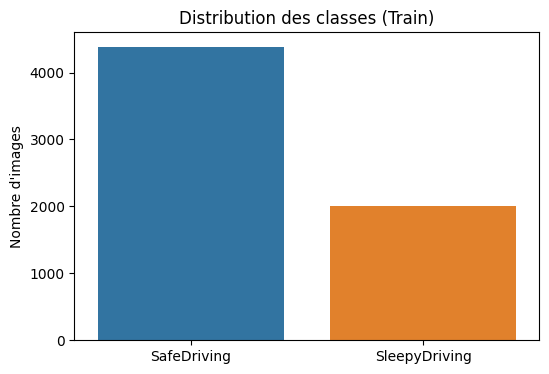

In [8]:
def plot_class_distribution(directory, title):
    classes = os.listdir(directory)
    counts = [len(os.listdir(os.path.join(directory, c))) for c in classes]

    plt.figure(figsize=(6,4))
    sns.barplot(x=classes, y=counts)
    plt.title(title)
    plt.ylabel("Nombre d'images")
    plt.show()

plot_class_distribution(TRAIN_DIR, "Distribution des classes (Train)")


## 4. Data Augmentation

La Data Augmentation est appliquée uniquement sur les données d’entraînement afin d’augmenter artificiellement la diversité du dataset.  
Les transformations choisies (rotation légère, translation, zoom, variation de luminosité) simulent des conditions réelles de conduite telles que les changements d’angle de caméra ou d’éclairage.

Nous évitons volontairement certaines transformations non réalistes, comme le retournement vertical, car elles ne correspondent pas à des situations réelles de conduite.  
Cette approche permet d’améliorer la robustesse du modèle sans introduire de biais artificiels.


In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.7,1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)


## 5. Chargement des Données

Les images sont chargées à l’aide de la fonction `flow_from_directory`, qui permet une lecture efficace des données directement depuis le disque.  
Le mode **binary** est utilisé puisque le problème est une classification binaire.

Les images en niveaux de gris sont automatiquement converties en images RGB, assurant ainsi une compatibilité totale avec l’architecture CNN sans nécessiter de prétraitement manuel supplémentaire.


In [10]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 6388 images belonging to 2 classes.
Found 1369 images belonging to 2 classes.
Found 1371 images belonging to 2 classes.


## 6. Visualisation des Images Augmentées

Cette étape permet de vérifier visuellement l’effet de la Data Augmentation sur les images d’entraînement.  
Elle garantit que les transformations appliquées sont cohérentes et qu’elles préservent les caractéristiques essentielles liées à l’état du conducteur.

Cette validation visuelle est cruciale pour éviter des transformations excessives pouvant nuire à l’apprentissage du modèle.


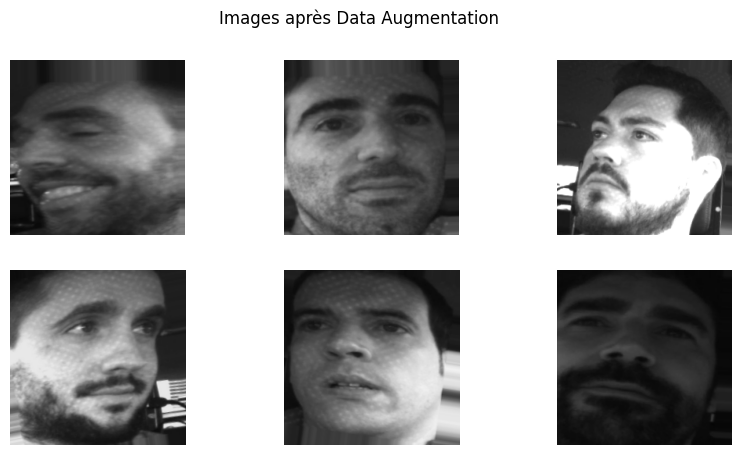

In [11]:
x_batch, y_batch = next(train_generator)

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_batch[i])
    plt.axis("off")

plt.suptitle("Images après Data Augmentation")
plt.show()


## 7. Gestion du Déséquilibre des Classes

Étant donné le déséquilibre potentiel entre les classes SafeDriving et SleepyDriving, nous utilisons la méthode des **class weights**.  
Cette technique attribue un poids plus élevé à la classe minoritaire afin d’augmenter son importance lors de l’apprentissage.

Contrairement au suréchantillonnage classique, cette approche évite la duplication d’images et limite ainsi le risque de surapprentissage.


In [12]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights :", class_weights)


Class Weights : {0: 0.72889091738932, 1: 1.5922233300099702}


## 8. Architecture CNN From Scratch

Nous avons conçu un réseau de neurones convolutifs from scratch composé de plusieurs blocs convolutionnels.  
Chaque bloc extrait progressivement des caractéristiques de plus en plus abstraites, allant des contours simples aux structures complexes du visage et des yeux.

L’ajout de la **Batch Normalization** stabilise l’apprentissage, tandis que le **Dropout** réduit le risque de surapprentissage.  
Le choix d’un CNN from scratch permet une meilleure compréhension du processus d’apprentissage et une adaptation spécifique au problème étudié.


In [13]:
cnn_model = Sequential()

cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Conv2D(256, (3,3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))

cnn_model.add(Flatten())
cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 222, 222, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 batch_normalization_1 (Bat  (None, 109, 109, 64)      256       
 chNormalization)                                                
                                                        

## 9. Compilation du Modèle

Le modèle est compilé avec l’optimiseur **Adam**, reconnu pour sa rapidité de convergence et sa stabilité.  
La fonction de perte **binary_crossentropy** est parfaitement adaptée aux problèmes de classification binaire.

Cette combinaison permet un apprentissage efficace tout en assurant une optimisation précise des paramètres du modèle.


In [14]:
cnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


## 10. Callbacks

Les callbacks permettent de contrôler dynamiquement le processus d’entraînement.  
La réduction automatique du taux d’apprentissage améliore la convergence, tandis que l’arrêt anticipé empêche le surapprentissage.

La sauvegarde du meilleur modèle garantit que la version la plus performante est conservée pour l’évaluation finale.


In [15]:
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint("best_SleepyDriving_CNN.h5", save_best_only=True)
]


## 11. Entraînement du Modèle

Le modèle est entraîné sur les données augmentées tout en étant évalué sur le jeu de validation.  
Cette stratégie permet de suivre l’évolution des performances et d’ajuster automatiquement les paramètres si nécessaire.

L’utilisation des class weights assure une prise en compte équilibrée des deux classes pendant l’apprentissage.


In [16]:
history = cnn_model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/5
200/200 [==============================] - ETA: 0s - loss: 0.6250 - accuracy: 0.7589

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


200/200 [==============================] - 643s 3s/step - loss: 0.6250 - accuracy: 0.7589 - val_loss: 0.5237 - val_accuracy: 0.7714 - lr: 1.0000e-04
Epoch 2/5
200/200 [==============================] - 486s 2s/step - loss: 0.4076 - accuracy: 0.8264 - val_loss: 0.4144 - val_accuracy: 0.8086 - lr: 1.0000e-04
Epoch 3/5
200/200 [==============================] - 476s 2s/step - loss: 0.3255 - accuracy: 0.8683 - val_loss: 0.2317 - val_accuracy: 0.9080 - lr: 1.0000e-04
Epoch 4/5
200/200 [==============================] - 448s 2s/step - loss: 0.2559 - accuracy: 0.8957 - val_loss: 0.1155 - val_accuracy: 0.9540 - lr: 1.0000e-04
Epoch 5/5
200/200 [==============================] - 592s 3s/step - loss: 0.2160 - accuracy: 0.9141 - val_loss: 0.0996 - val_accuracy: 0.9627 - lr: 1.0000e-04


## 12. Courbes Accuracy et Loss

Les courbes d’accuracy et de loss permettent d’analyser le comportement du modèle au cours de l’entraînement.  
Elles aident à détecter les phénomènes de sous-apprentissage ou de surapprentissage.

Cette analyse visuelle constitue un outil essentiel pour valider la stabilité et la généralisation du modèle.


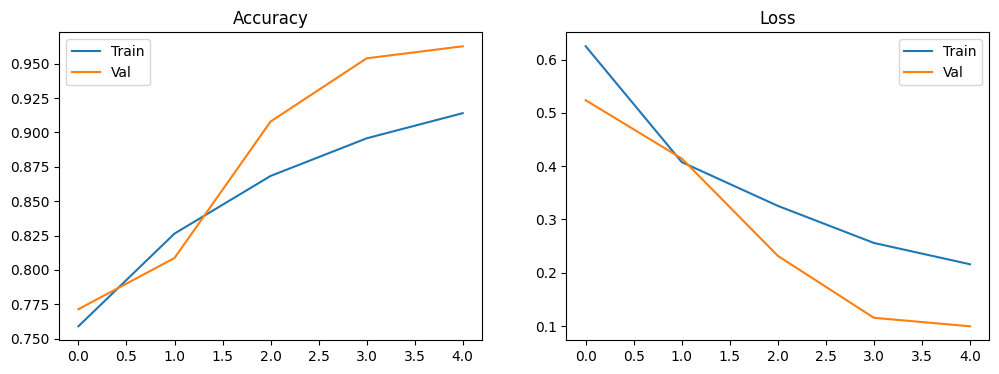

In [17]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.show()


## 13. Évaluation sur le Jeu de Test

L’évaluation sur le jeu de test fournit une mesure objective des performances finales du modèle.  
Contrairement aux données d’entraînement, ces images n’ont jamais été vues par le modèle, garantissant ainsi une évaluation impartiale.


In [18]:
test_loss, test_acc = cnn_model.evaluate(test_generator)
print("Test Accuracy :", test_acc)


43/43 [==============================] - 44s 1s/step - loss: 0.0820 - accuracy: 0.9716
Test Accuracy : 0.9715536236763


## 14. Matrice de Confusion

La matrice de confusion permet d’analyser finement les erreurs de classification.  
Elle met en évidence les faux positifs et faux négatifs, particulièrement critiques dans le contexte de la détection de somnolence au volant.


43/43 [==============================] - 21s 465ms/step


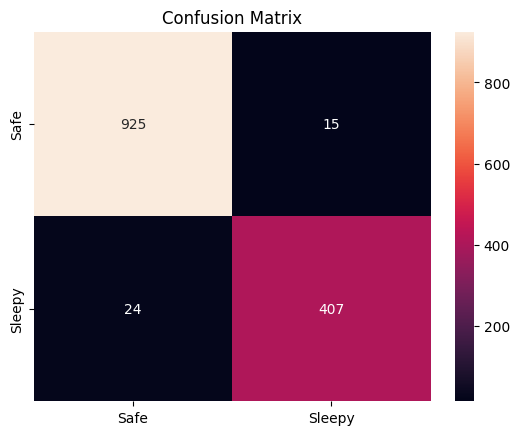

In [19]:
y_true = test_generator.classes
y_pred = (cnn_model.predict(test_generator) > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Safe', 'Sleepy'],
            yticklabels=['Safe', 'Sleepy'])
plt.title("Confusion Matrix")
plt.show()


## 15. Rapport de Classification

Le rapport de classification fournit des métriques détaillées telles que la précision, le rappel et le F1-score.  
Ces indicateurs sont essentiels pour évaluer la performance du modèle, en particulier sur la classe SleepyDriving.


In [20]:
print(classification_report(
    y_true, y_pred,
    target_names=['SafeDriving', 'SleepyDriving']
))


               precision    recall  f1-score   support

  SafeDriving       0.97      0.98      0.98       940
SleepyDriving       0.96      0.94      0.95       431

     accuracy                           0.97      1371
    macro avg       0.97      0.96      0.97      1371
 weighted avg       0.97      0.97      0.97      1371



## 16. Courbe ROC

La courbe ROC illustre le compromis entre le taux de faux positifs et le taux de vrais positifs.  
L’aire sous la courbe (AUC) fournit une mesure globale de la capacité discriminante du modèle.


43/43 [==============================] - 19s 440ms/step


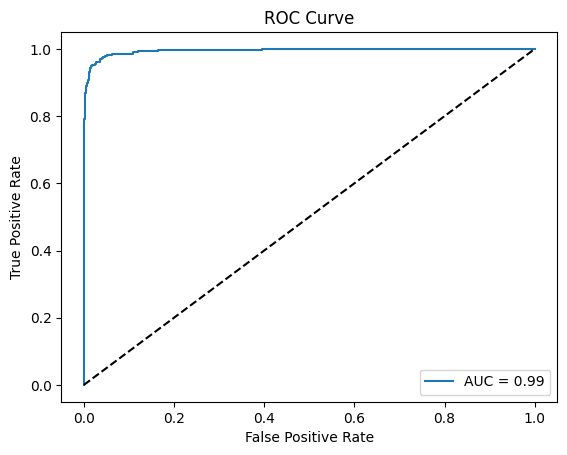

In [21]:
y_score = cnn_model.predict(test_generator)

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Conclusion

Dans ce projet, nous avons développé un système complet de détection de la somnolence au volant basé sur le Deep Learning.  
À travers une approche rigoureuse incluant la préparation des données, l’augmentation, la gestion du déséquilibre et l’évaluation approfondie, le modèle a démontré des performances prometteuses.

Ce travail constitue une base solide pour des améliorations futures, notamment l’intégration de modèles pré-entraînés, l’analyse en temps réel ou l’extension à des scénarios multimodaux (vidéo, capteurs).  
Il illustre également l’importance du Deep Learning dans le domaine de la sécurité routière et des systèmes intelligents.
